[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lshofsl/Thesis/blob/main/NCA_mod.ipynb)

In [1]:
import os
import sys

!rm -rf Thesis
!git clone https://github.com/lshofsl/Thesis

repo_path = os.path.abspath("Thesis")
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

if os.path.exists(repo_path):
    print("Success! Files now found:", os.listdir(repo_path))

Cloning into 'Thesis'...
remote: Enumerating objects: 358, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 358 (delta 67), reused 76 (delta 32), pack-reused 227 (from 1)
Receiving objects: 100% (358/358), 4.65 MiB | 17.57 MiB/s, done.
Resolving deltas: 100% (172/172), done.
Success! Files now found: ['GeneNCA_RA.ipynb', 'README.md', '.git', 'NCA_w_RAmod.ipynb', 'Thesis_progress.pdf', 'NCA_baseline.ipynb', 'requirements.txt', 'NCA', 'Images', 'NCA_mod.ipynb', 'EngramNCA.ipynb', 'NCA_with_only_modulation.ipynb']


In [2]:
#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import os
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA.NCA_gene import *
import NCA.utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from sklearn.decomposition import PCA
from PIL import Image
import cv2
from base64 import b64encode
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)


Using device: cuda


In [3]:
#@title Setup { vertical-output: true}
HEIGHT = 30 #@param {type:"integer"}
WIDTH = 30 #@param {type:"integer"}
CHANNELS = 19 # @param {type:"integer"}<--- NCA baseline + mod channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
GENE_COUNT = 3 #@param {type:"integer"} <-- Number of gene channels to use for "private" information
RECURRENT_CHANNELS = 3 #@param {type:"integer"} <-- Number of channels for RA computation, these channels are not updated by the NCA and are only used for recurrent processing
MODULATORY_OUTPUT = 3 #@param {type:"integer"} <-- Number of channels for modulatory output, these channels are not updated  and only show the output of the NCA
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 10000  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size

style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""

In [4]:
#@title Load Primitives { vertical-output: true}

LIZARD = "Images/lizard.png"
SQUARE = "Images/square.png"
path = LIZARD
image, image_to_display = utils.get_image(os.path.join(repo_path, path), HEIGHT, WIDTH, padding=PADDING)

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING

In [5]:
class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

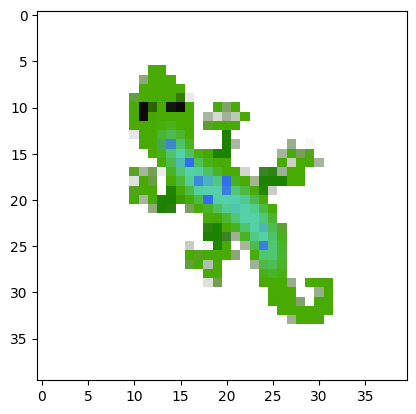

In [6]:
seed = np.zeros([CHANNELS, HEIGHT, WIDTH], np.float32)
seed[3:, HEIGHT // 2, WIDTH // 2] = 1.0

pool = SamplePool(x=np.repeat(seed[None, ...], POOL_SIZE, axis=0))


plt.imshow(image_to_display)
plt.show()

In [7]:
#@title Get Batch Image Partitions { vertical-output: true}
batch = pool.sample(BATCH_SIZE)

In [8]:
#@title Load Filters for Loss Function { vertical-output: true}
sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "NCA"

In [9]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")

Path: Trained_models/NCA created


In [10]:
#@title Initialise NCA { vertical-output: true}
base = image.tile(BATCH_SIZE, 1, 1, 1).to(DEVICE)
loss_log = []
nca = NCA_onlymod(public=16, m_dim=3, hidden_n=HIDDEN_SIZE, m_mode='fixed')
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" + type(nca).__name__

Batch


/tmp/ipykernel_657/3360791306.py:84: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 4))


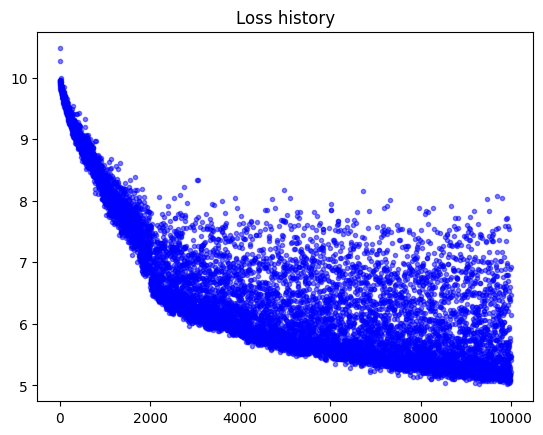

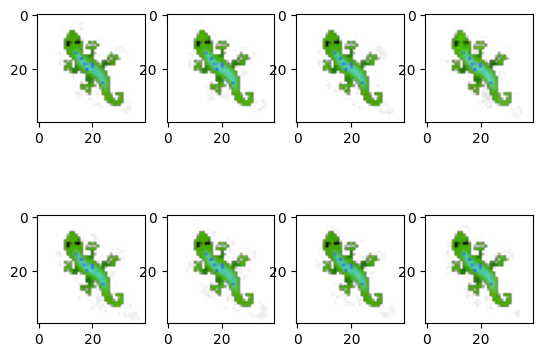

Trained_models/NCA/NCA_onlymod.pth


In [11]:
#@title Training { vertical-output: true}

hidden_layers = []
hidden_corr = []
hidden_layers_iters = []
pca_maps = []
gamma_mean = []
gamma_std = []
beta_mean = []
beta_std = []
pca = None
PCA_REFIT_EVERY = 500
LOG_HIDDEN_EVERY = 100


for i in range(TRAINING_ITERS + 1):
    with torch.no_grad():
        batch = pool.sample(BATCH_SIZE)
        x = torch.from_numpy(batch.x).to(DEVICE)

    for _ in range(random.randrange(32, 92)):
        x = nca(x)

    per_sample_loss = (base - x[:, :4, :, :]).pow(2).sum(dim=[1, 2, 3])
    reg = 0.1 * (
        perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters)
    ).pow(2).sum()
    loss = per_sample_loss.sum() + reg

    loss.backward()
    with torch.no_grad():
        for p in nca.parameters():
            p.grad /= (p.grad.norm() + 1e-8)
        optim.step()
        x = x.detach()
        optim.zero_grad()

    loss_log.append(loss.log().item())
    with torch.no_grad():
        loss_rank = per_sample_loss.detach().cpu().numpy().argsort()[::-1]
        x_np = x.detach().cpu().numpy()[loss_rank]
        x_np[:1] = seed
        batch.x[:] = x_np
        batch.commit()
    scheduler.step()


    with torch.no_grad():
        visible = x[:, :4, :, :]
        hidden = x[:, 4:16, :, :]

        B, n_vis, H, W = visible.shape
        n_hid = hidden.shape[1]

        v_flat = visible.permute(0, 2, 3, 1).reshape(-1, n_vis)
        h_flat = hidden.permute(0, 2, 3, 1).reshape(-1, n_hid)

        living_mask = v_flat[:, 3] > 0.1

        if living_mask.sum() < 10:
            hidden_corr.append(float('nan'))
        else:
            h_live = h_flat[living_mask].cpu().numpy()
            if n_hid > 1:
                cc_hh = np.abs(np.corrcoef(h_live, rowvar=False))
                hh_val = np.mean(cc_hh[np.triu_indices(n_hid, k=1)])
            else:
                hh_val = 0.0
            hidden_corr.append(hh_val)

            if i % LOG_HIDDEN_EVERY == 0:
                hidden_layers.append(h_live)
                hidden_layers_iters.append(i)

        if i % PCA_REFIT_EVERY == 0 and len(hidden_layers) > 0:
            pooled = np.concatenate(hidden_layers, axis=0)
            pca = PCA(n_components=2)
            pca.fit(pooled)

    if i % 100 == 0:
        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1, figsize=(10, 4))
        plt.title('Loss history')
        plt.plot(loss_log, '.', alpha=0.5, color="b")
        print("Batch")
        utils.show_batch(x[2:14])
        display(HTML(style))
        plt.show(block=False)
        plt.pause(0.01)
        #gamma_mean.append(nca.film_gamma.mean().item())
        #gamma_std.append(nca.film_gamma.std().item())
        #beta_mean.append(nca.film_beta.mean().item())
        #beta_std.append(nca.film_beta.std().item())

    if pca is not None and i % 10 == 0:
        grid0_hidden = hidden[0]
        grid0_alive = (visible[0, 3] > 0.1).cpu().numpy()

        h_grid_flat = grid0_hidden.permute(1, 2, 0).reshape(-1, n_hid).cpu().numpy()
        proj = pca.transform(h_grid_flat)
        PC1_map = proj[:, 0].reshape(H, W)
        PC2_map = proj[:, 1].reshape(H, W)

        pca_maps.append((i, PC1_map, PC2_map, grid0_alive))

    if i % 100 == 0:
        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")
        print("Trained_models/" + name + ".pth")

In [12]:
del nca
del optim
torch.cuda.empty_cache()

In [14]:
nca = NCA_onlymod(public=16, m_dim=3, hidden_n=HIDDEN_SIZE, m_mode='fixed')
nca.load_state_dict(torch.load("Trained_models/NCA/NCA_onlymod.pth"))
nca.to(DEVICE).eval()

NCA_onlymod(
  (w1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (film_gamma): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  (film_beta): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
)

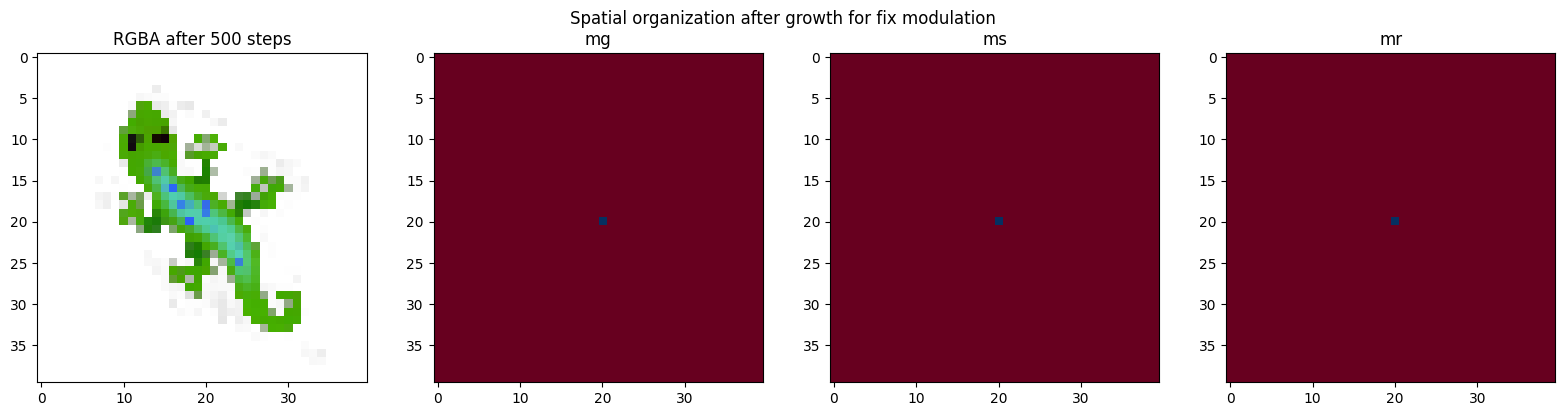

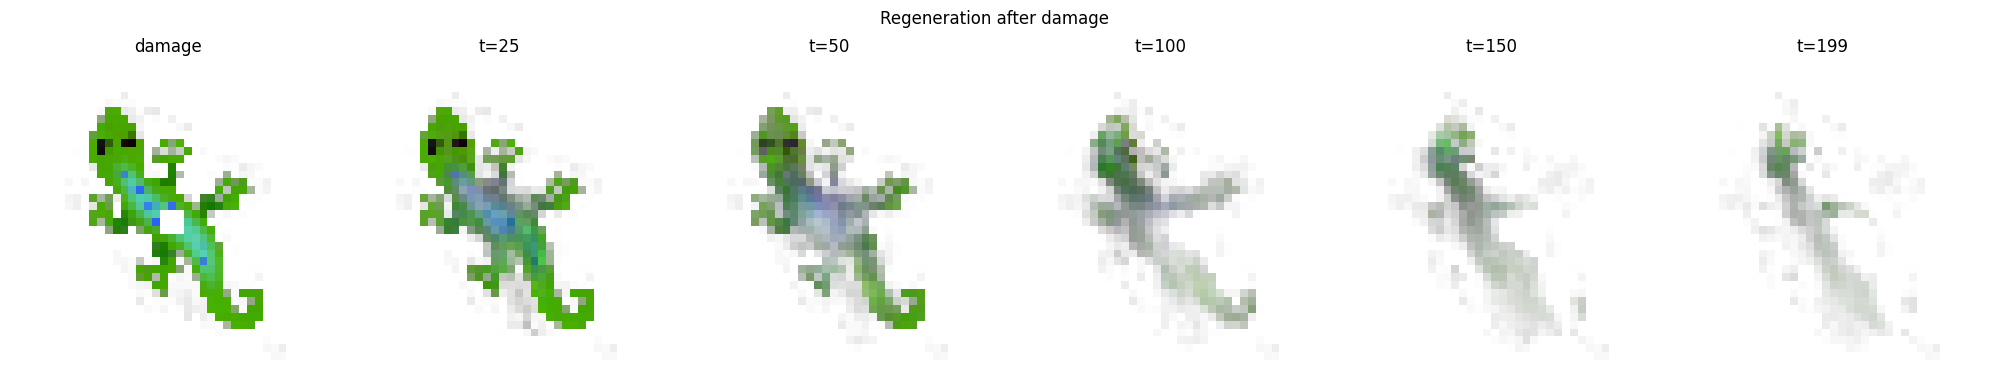

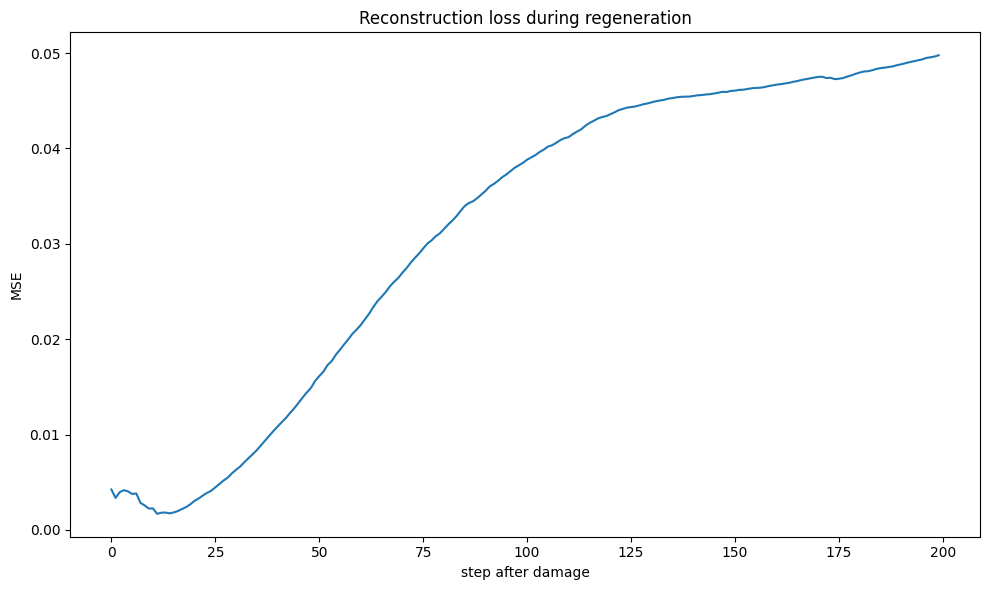

In [15]:
with torch.no_grad():
    # Start from a pool sample — guaranteed good starting state
    x_test = torch.from_numpy(seed[None, ...]).to(DEVICE) if isinstance(seed, np.ndarray) else seed.to(DEVICE)

    # Grow for 100 steps
    for t in range(500):
        x_test = nca(x_test)

    # --- Plot 1: What it looks like after growth ---
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(x_test[0, :4].permute(1,2,0).cpu().clip(0,1))
    axes[0].set_title('RGBA after 500 steps')
    axes[1].imshow(x_test[0, 16].cpu(), cmap='RdBu')
    axes[1].set_title('mg')
    axes[2].imshow(x_test[0, 17].cpu(), cmap='RdBu')
    axes[2].set_title('ms')
    axes[3].imshow(x_test[0, 18].cpu(), cmap='RdBu')
    axes[3].set_title('mr')
    plt.suptitle('Spatial organization after growth for fix modulation')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Damage experiment ---
    x_damaged = x_test.clone()
    _, _, H, W = x_damaged.shape

# 2. Define the circle's center and radius
# (Defaulting to the exact center of the image, with a radius of 15% of the width)
    center_y, center_x = H // 2, W // 2
    radius = int(0.05 * min(H, W))

# 3. Create a 2D coordinate grid of (y, x) coordinates
    y_indices = torch.arange(H).view(H, 1)
    x_indices = torch.arange(W).view(1, W)

# 4. Calculate the squared Euclidean distance from the center for every pixel
    distance_squared = (y_indices - center_y) ** 2 + (x_indices - center_x) ** 2

# 5. Create a boolean mask where True means "inside the circle"
# (Using distance^2 < radius^2 to avoid slow square root operations)
    circular_mask = distance_squared < (radius ** 2)

# 6. Apply the mask across all batches and channels
# (PyTorch automatically broadcasts the [H, W] mask to [B, C, H, W])
    x_damaged[:, :, circular_mask] = 0

    frames_damaged = [x_damaged[0, :4].permute(1,2,0).cpu().clip(0,1)]
    losses = []
    for t in range(200):
        x_damaged= nca(x_damaged)
        losses.append((base - x_damaged[:, :4]).pow(2).mean().item())
        if t in [25, 50, 100, 150, 199]:
            frames_damaged.append(
                x_damaged[0, :4].permute(1,2,0).cpu().clip(0,1)
            )

    # Show regeneration frames
    fig, axes = plt.subplots(1, len(frames_damaged), figsize=(20, 4))
    titles = ['damage'] + [f't={t}' for t in [25, 50, 100, 150, 199]]
    for ax, frame, title in zip(axes, frames_damaged, titles):
        ax.imshow(frame)
        ax.set_title(title)
        ax.axis('off')
    plt.suptitle('Regeneration after damage')
    plt.tight_layout()
    plt.show()

    # --- Plot 3: RA amplitude and loss over regeneration ---
    fig,ax2 = plt.subplots(1, 1, figsize=(10, 6))
    ax2.plot(losses)
    ax2.set_title('Reconstruction loss during regeneration')
    ax2.set_ylabel('MSE')
    ax2.set_xlabel('step after damage')
    plt.tight_layout()
    plt.show()


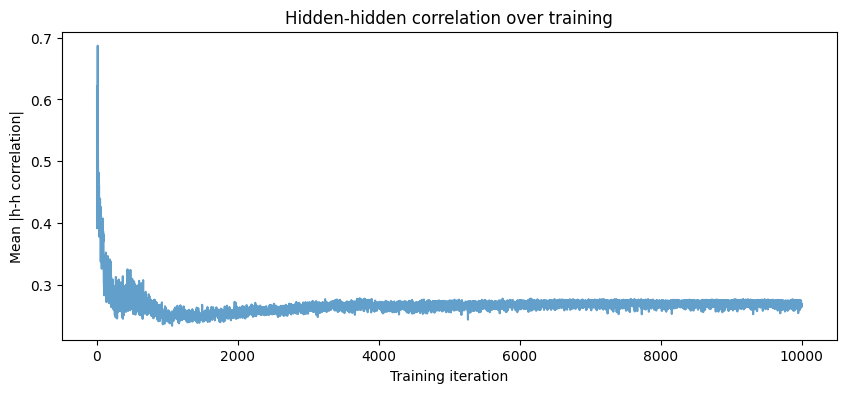

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(hidden_corr, alpha=0.7)
plt.xlabel("Training iteration")
plt.ylabel("Mean |h-h correlation|")
plt.title("Hidden-hidden correlation over training")
plt.show()

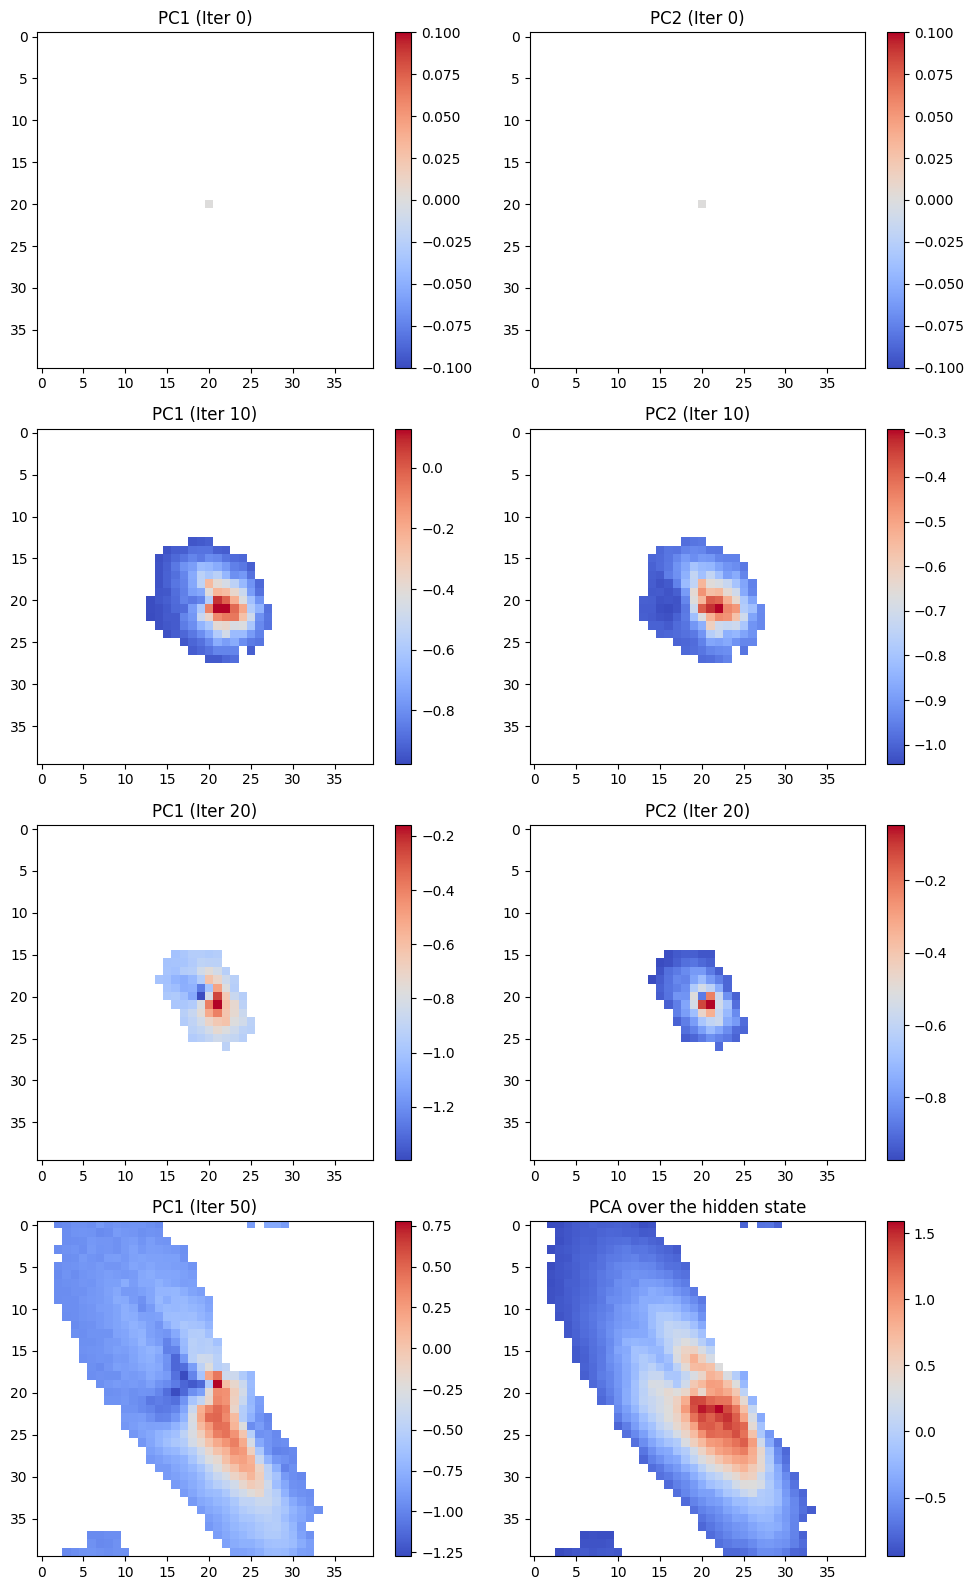

In [17]:
pca_maps_by_iter = {it: (PC1_map, PC2_map, alive_mask) for (it, PC1_map, PC2_map, alive_mask) in pca_maps}

requested_iters = [0, 10, 20, 50]
available_iters = [it for it in requested_iters if it in pca_maps_by_iter]

num_rows = len(available_iters)
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 4 * num_rows))

if num_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, it in enumerate(available_iters):
    PC1_map, PC2_map, alive_mask = pca_maps_by_iter[it]

    for col_idx, (pc_map, name) in enumerate(zip([PC1_map, PC2_map], ['PC1', 'PC2'])):
        ax = axes[row_idx, col_idx]
        masked = np.where(alive_mask, pc_map, np.nan)

        im = ax.imshow(masked, cmap='coolwarm')
        ax.set_title(f"{name} (Iter {it})")

        fig.colorbar(im, ax=ax)
plt.title("PCA over the hidden state")
plt.tight_layout()
plt.show()


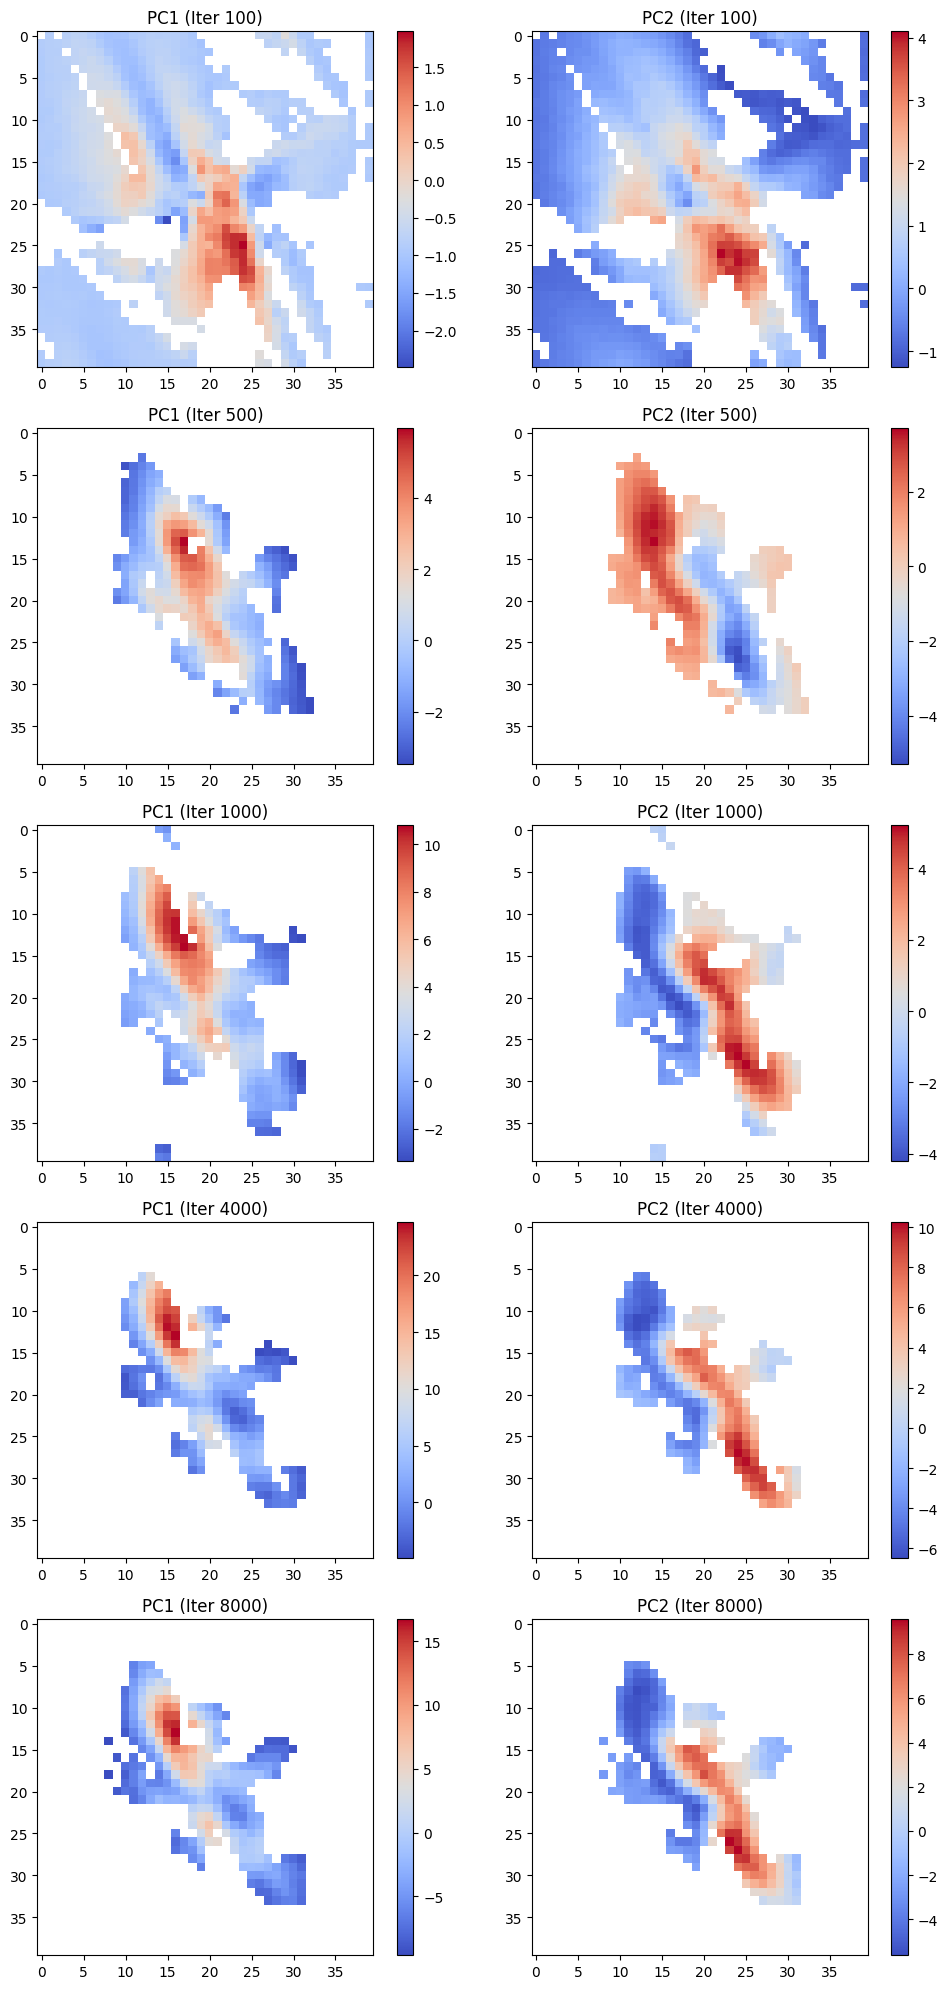

In [18]:
pca_maps_by_iter = {it: (PC1_map, PC2_map, alive_mask) for (it, PC1_map, PC2_map, alive_mask) in pca_maps}

requested_iters = [100, 500, 1000, 4000, 8000]
available_iters = [it for it in requested_iters if it in pca_maps_by_iter]

num_rows = len(available_iters)
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 4 * num_rows))

if num_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, it in enumerate(available_iters):
    PC1_map, PC2_map, alive_mask = pca_maps_by_iter[it]

    for col_idx, (pc_map, name) in enumerate(zip([PC1_map, PC2_map], ['PC1', 'PC2'])):
        ax = axes[row_idx, col_idx]
        masked = np.where(alive_mask, pc_map, np.nan)

        im = ax.imshow(masked, cmap='coolwarm')
        ax.set_title(f"{name} (Iter {it})")

        fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

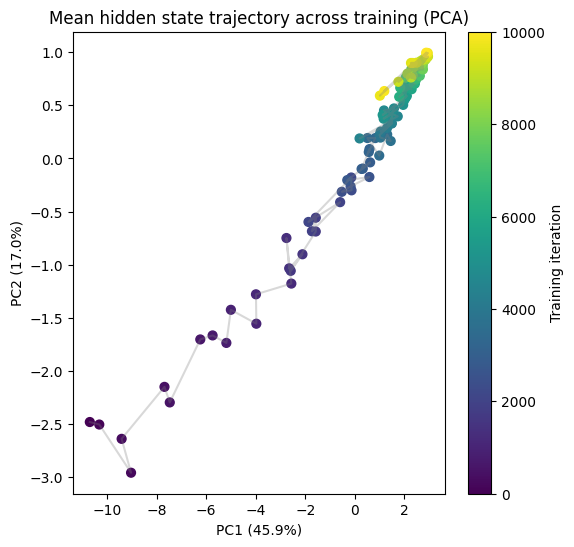

In [19]:
pooled = np.concatenate(hidden_layers, axis=0)
pca = PCA(n_components=2)
pca.fit(pooled)

means, stds = [], []
for h_live in hidden_layers:
    proj = pca.transform(h_live)
    means.append(proj.mean(axis=0))
    stds.append(proj.std(axis=0))
means = np.array(means)
stds = np.array(stds)

plt.figure(figsize=(6, 6))
sc = plt.scatter(means[:, 0], means[:, 1], c=hidden_layers_iters, cmap='viridis', s=40)
plt.plot(means[:, 0], means[:, 1], alpha=0.3, color='gray')
plt.colorbar(sc, label="Training iteration")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Mean hidden state trajectory across training (PCA)")
plt.show()

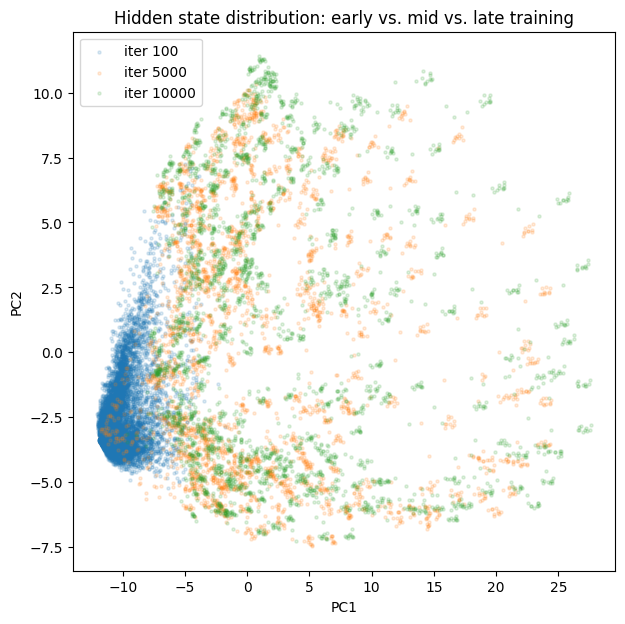

In [20]:
plt.figure(figsize=(7, 7))
snap_indices_to_show = [1, len(hidden_layers)//2, len(hidden_layers)-1]
colors = ['tab:blue', 'tab:orange', 'tab:green']
for si, color in zip(snap_indices_to_show, colors):
    proj = pca.transform(hidden_layers[si])
    plt.scatter(proj[:, 0], proj[:, 1], alpha=0.15, s=5, color=color,
                label=f"iter {hidden_layers_iters[si]}")
plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hidden state distribution: early vs. mid vs. late training")
plt.show()

In [21]:
def apply_damage(x, damage_type='right_half', circle_radius=5):
    """
    Apply different damage patterns to a cell state.

    damage_type options:
        'right_half'   — remove right half (your original)
        'left_half'    — remove left half
        'center_circle'— remove a circle from the center
        'small_circle' — remove a small circle (severe local damage)
        'random'       — randomly zero out 50% of cells
        'cross'        — remove a cross through the center
    """
    x = x.clone()
    _, _, H, W = x.shape
    cy, cx = H // 2, W // 2  # center coordinates

    if damage_type == 'right_half':
        x[:, :, :, W//2:] = 0

    elif damage_type == 'left_half':
        x[:, :, :, :W//2] = 0

    elif damage_type == 'center_circle':
        # Remove a large circle from center
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= circle_radius**2
        x[:, :, mask] = 0

    elif damage_type == 'small_circle':
        # Severe: remove a tiny circle — forces regeneration from very little
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) > circle_radius**2
        x[:, :, mask] = 0  # keep ONLY the small circle, destroy everything else

    elif damage_type == 'random':
        noise = torch.rand(1, 1, H, W, device=x.device) > 0.5
        x = x * noise.float()

    elif damage_type == 'cross':
        thickness = max(1, H // 10)
        x[:, :, cy - thickness:cy + thickness, :] = 0
        x[:, :, :, cx - thickness:cx + thickness] = 0

    return x



def visualize_regeneration(nca, seed, base, damage,
                            channels=4, steps=501, device=DEVICE):

    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.to(device)
    with torch.no_grad():
        for _ in range(500):
            x = nca(x)

    # Damage: remove right half
    x = apply_damage(x, damage)

    frames        = [x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()]
    loss_recovery = []
    capture_steps = [25, 50, 100, 150, 200, 500]

    with torch.no_grad():
        for t in range(steps):
            x = nca(x)
            l = (base[0:1] - x[:, :4]).pow(2).mean().item()
            loss_recovery.append(l)

            if t in capture_steps:
                frames.append(
                    x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()
                )

    fig = plt.figure(figsize=(20, 9))

    titles = ['damaged'] + [f't={t}' for t in capture_steps]
    for i, (frame, title) in enumerate(zip(frames, titles)):
        ax = fig.add_subplot(2, len(frames), i + 1)
        ax.imshow(frame)
        ax.set_title(title)
        ax.axis('off')

    ax_loss = fig.add_subplot(2, 2, 3)
    ax_loss.plot(loss_recovery, color='blue', linewidth=1.5)
    ax_loss.set_title("Reconstruction Loss During Recovery")
    ax_loss.set_xlabel("NCA Steps")
    ax_loss.set_ylabel("MSE Loss")
    ax_loss.grid(True, alpha=0.3)
    for t in capture_steps:
        ax_loss.axvline(x=t, color='gray', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_657/177747804.py:92: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


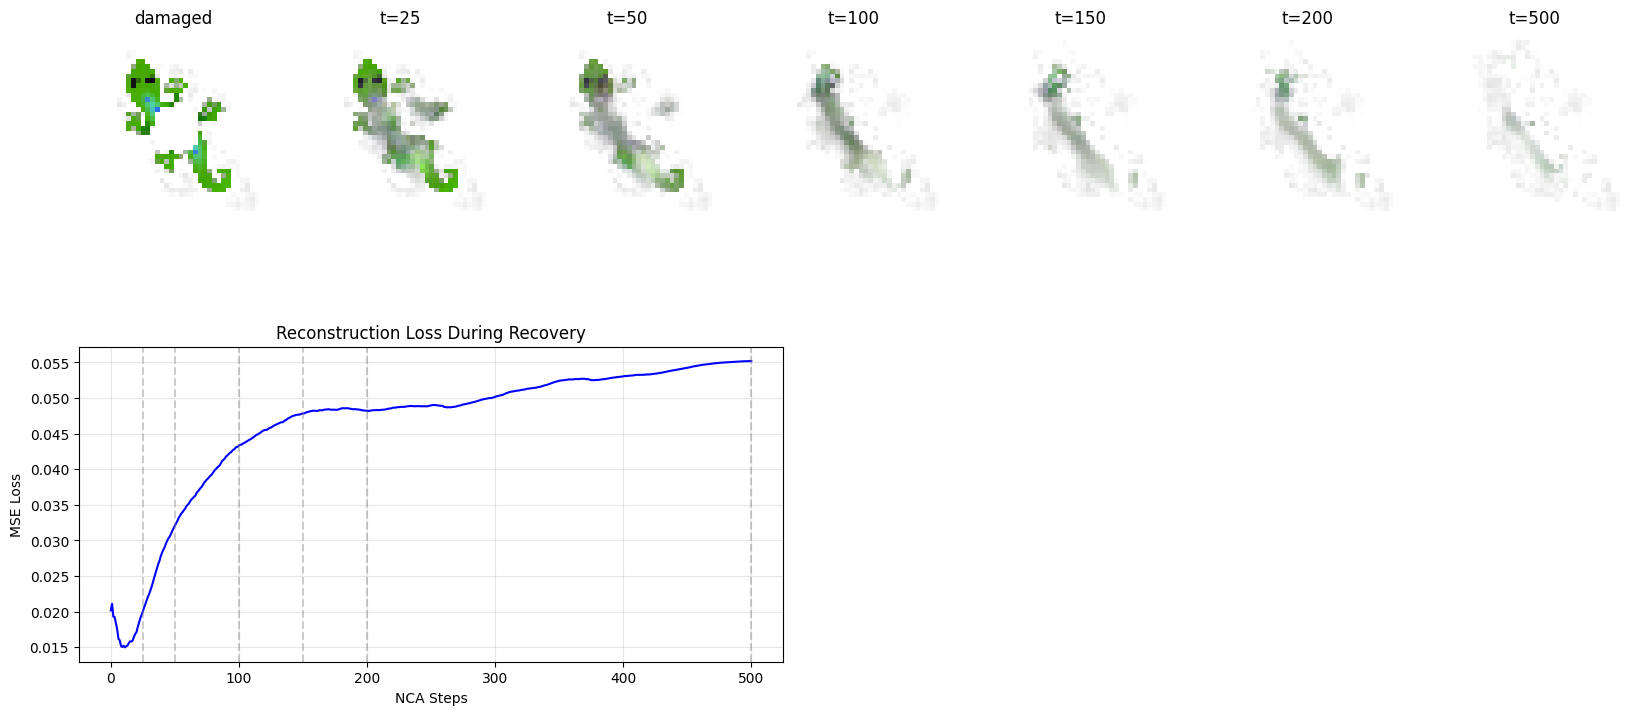

In [22]:
visualize_regeneration(nca, seed, base, "center_circle")

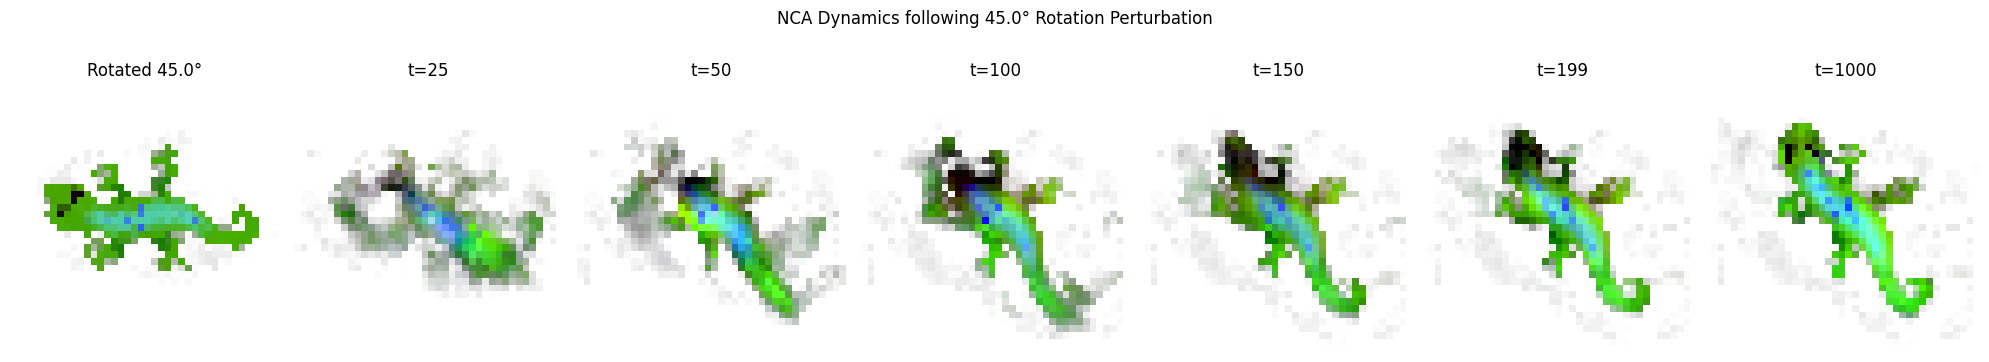

In [23]:
import torchvision.transforms.v2.functional as TF

ROTATION_ANGLE = 45.0  # Try 45, 90, or 180 degrees

# 1. Rotate x_test
x_rotated = TF.rotate(x_test.clone(), angle=ROTATION_ANGLE)

amps_rot, losses_rot = [], []

# Use .detach() before moving to CPU/NumPy
frames_rotated = [x_rotated[0, :4].permute(1, 2, 0).detach().cpu().clip(0, 1)]

# 2. Run NCA rollouts on the rotated state
with torch.no_grad():  # Prevents building unused grad graphs
    for t in range(1001):
        x_rotated= nca(x_rotated)
        losses_rot.append((base[0:1] - x_rotated[:, :4]).pow(2).mean().item())

        if t in [25, 50, 100, 150, 199, 1000]:
            frames_rotated.append(
                x_rotated[0, :4].permute(1, 2, 0).detach().cpu().clip(0, 1)
            )

    # 3. Show rotation recovery frames
fig, axes = plt.subplots(1, len(frames_rotated), figsize=(20, 4))
titles = [f'Rotated {ROTATION_ANGLE}°'] + [f't={t}' for t in [25, 50, 100, 150, 199, 1000]]
for ax, frame, title in zip(axes, frames_rotated, titles):
    ax.imshow(frame)
    ax.set_title(title)
    ax.axis('off')
plt.suptitle(f'NCA Dynamics following {ROTATION_ANGLE}° Rotation Perturbation')
plt.tight_layout()
plt.show()

In [23]:
del nca
torch.cuda.empty_cache()